# Fine-Wine -- a quantitative teardown
### Liv-ex 100 * S&P 500 * Geltner de-smoothing * 2-asset frontier * gross/net x raw/de-smoothed * Newey-West HAC * n=22 power

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Busted%3F: Yes](https://img.shields.io/badge/Busted%3F-Yes-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) -- *same seven beats, every claim carrying its standard error.* We measure the Liv-ex 100's correlation with the S&P 500 raw and after Geltner first-order unsmoothing, build the two-asset mean-variance frontier, evaluate the diversification benefit of a wine sleeve across four lenses (gross/net x raw/de-smoothed) with Newey-West HAC t-stats, and close with the n=22 power reckoning.

> **Not investment advice.** Real data: Liv-ex 100 year-end levels hardcoded in `data.py` (2003-2025); S&P 500 from the repo `^GSPC` cache (Dec/Dec, price-only). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> **The plain-English notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY, PURPLE = "#c0392b", "#dab617", "#2ea44f", "#8b949e", "#7d3c98"

from fine_wine import data, strategy as st

def _have_cache():
    try:
        data.fetch_sp500_annual()
        return True
    except FileNotFoundError:
        return False

HAVE_REAL = _have_cache()
print("^GSPC cache present:", HAVE_REAL)

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-17)
R = dict(
    n=22, year_start=2004, year_end=2025,
    wine_cagr_pct=4.7, eq_cagr_pct=8.6,
    wine_vol_pct=14.1, wine_vol_desmoothed_pct=19.4, eq_vol_pct=16.3,
    wine_sharpe=0.251, eq_sharpe=0.490,
    raw_corr=0.097, wine_ar1=0.306, desmoothed_corr=0.277,
    eq_only_sharpe=0.490,
    blend_sharpe_gross_raw=0.522, blend_sharpe_net_raw=0.477,
    blend_sharpe_gross_desmoothed=0.484, blend_sharpe_net_desmoothed=0.442,
    sharpe_delta_net_desmoothed=-0.047,
    benefit_hac_t_gross_raw=-0.817, benefit_hac_t_net_desmoothed=-1.346,
    best_weight_pct=34, best_sharpe=0.531,
)

from scipy import stats as scipy_stats


^GSPC cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Raw corr **+0.10**; wine AR(1) **+0.31**; de-smoothed corr **+0.28**. A real-but-modest equity beta, not a zero-correlation diversifier. No benefit HAC t reaches +2 (best **−0.82**). |
| **Tradability** | `MIRAGE` | Wine CAGR **4.7%** vs equity **8.6%**; net-of-cost, de-smoothed 20% sleeve Sharpe **0.442 < 0.490** (delta **−0.047**). |
| **Busted?** | `YES` | The low correlation is largely an appraisal-smoothing artefact; it de-smooths away and costs finish the job. |

> The diversification 'benefit' lives entirely in the gross/raw lens, and even there the per-year HAC t-stat is negative.

## 1 - The claim, steelmanned

Let $w_t$ be the Liv-ex 100 annual return and $e_t$ the S&P 500 annual return. The diversification pitch is:

- **H1 (low correlation).** $\rho(w, e) \approx 0$ -- wine is largely uncorrelated with equities.
- **H2 (benefit).** Adding a wine weight $\theta$ raises the portfolio Sharpe: $SR(\theta w + (1-\theta) e) > SR(e)$, *net of costs*.

The honesty correction: the observed $w_t$ is a **smoothed** version of the true wine return. If $w^{obs}_t = \phi\, w^{obs}_{t-1} + (1-\phi)\, w^{true}_t$, then $\rho(w^{obs}, e) < \rho(w^{true}, e)$ whenever $\phi > 0$. The Geltner inversion $w^{true}_t = (w^{obs}_t - \phi\, w^{obs}_{t-1})/(1-\phi)$ recovers the underlying. We test H1 raw and de-smoothed, and H2 across gross/net x raw/de-smoothed.

## 2 - So what? -- what rides on each answer

Fine wine is the archetype of an *illiquid alternative sold on a smoothed index*. The same Geltner critique applies to private real estate, private equity, art and many hedge-fund strategies: a mark-to-model series understates volatility and correlation, flattering Sharpe ratios and diversification math. If wine's apparent diversification is a smoothing artefact, that's a general lesson about how alternatives are marketed -- not a fact about Bordeaux.

## 3 - How we'd know -- the protocol

- **Data.** Liv-ex 100 December levels (hardcoded `data.py`, 2003-2025) -> 22 annual returns; S&P 500 `^GSPC` Dec/Dec price returns 2004-2025. Both **price-only** (equity excludes dividends ~1.8pp/yr; wine pays no income and costs carry).
- **De-smoothing.** $\phi$ = first-order autocorrelation of $w^{obs}$; Geltner inversion.
- **Frontier.** Sharpe across the long-only wine-weight grid (rf 2%).
- **Benefit + costs.** Wine one-way spread 10% on rebalanced notional + 1%/yr storage; equity 5bps; annual rebalance (one-year execution lag implicit). Four lenses: gross/net x raw/de-smoothed.
- **Inference.** Newey-West HAC (2 lags) t-stat on the per-year blend-minus-equity excess return.
- **Positive control.** Synthetic tape with planted correlation under planted smoothing.


## 4 - The teardown

### 4a - Risk and return, with the de-smoothed volatility

The de-smoothed wine series has materially higher volatility than the reported one.

In [2]:
if HAVE_REAL:
    df = data.fetch_sp500_annual()
    s = st.summarize(df)
    fp = data.fingerprint(df)
else:
    s = {k: R[k] for k in ('wine_cagr_pct','eq_cagr_pct','wine_vol_pct',
         'wine_vol_desmoothed_pct','eq_vol_pct','wine_sharpe','eq_sharpe',
         'raw_corr','wine_ar1','desmoothed_corr')}
    s['n'] = R['n']; fp = 'FROZEN'

print(f'Data stamp: n={s["n"]} years, fingerprint={fp}')
tbl = pd.DataFrame({
    'metric': ['CAGR %','vol (raw) %','vol (de-smoothed) %','Sharpe (rf2%)'],
    'wine':   [s['wine_cagr_pct'], s['wine_vol_pct'],
               s['wine_vol_desmoothed_pct'], s['wine_sharpe']],
    'equity': [s['eq_cagr_pct'], s['eq_vol_pct'], np.nan, s['eq_sharpe']],
})
print(tbl.to_string(index=False))
print()
print(f'Reported wine vol {s["wine_vol_pct"]:.1f}% understates the de-smoothed '
      f'{s["wine_vol_desmoothed_pct"]:.1f}% -- the smoothing discount on risk.')

Data stamp: n=22 years, fingerprint=4d28cad3df77
             metric   wine  equity
             CAGR %  4.700    8.60
        vol (raw) % 14.100   16.30
vol (de-smoothed) % 19.400     NaN
      Sharpe (rf2%)  0.251    0.49

Reported wine vol 14.1% understates the de-smoothed 19.4% -- the smoothing discount on risk.


Wine's **reported** 14.1% volatility is an undercount; de-smoothed it is **19.4%** -- *higher* than the S&P's 16.3%. So the honest picture is a lower-return (4.7% vs 8.6%), *higher*-risk asset. The flattering Sharpe of mid-price wine is an artefact of the same smoothing that flatters its correlation.

### 4b - Raw vs de-smoothed correlation (the Geltner correction)

Smoothing depresses measured correlation; the inversion restores it.

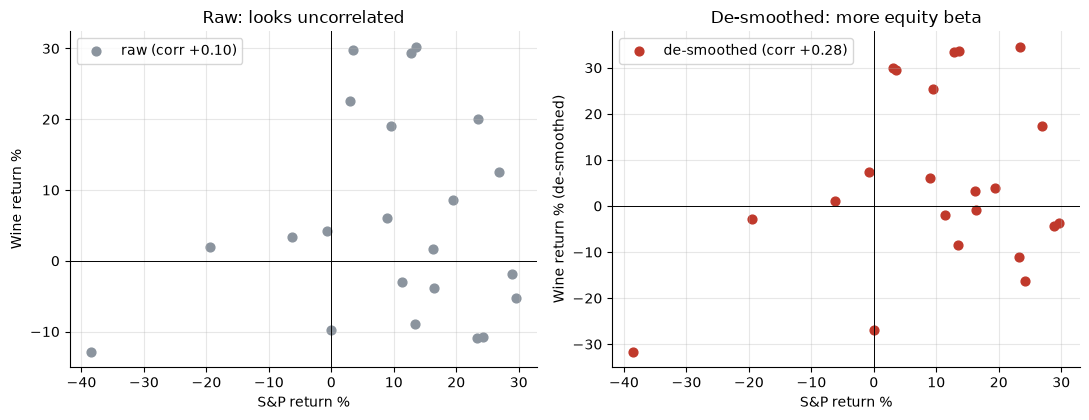

Wine AR(1) phi:          +0.306
Raw correlation:         +0.097
De-smoothed correlation: +0.277
Smoothing hid +0.180 of correlation.


In [3]:
if HAVE_REAL:
    w = df['wine_return'].to_numpy()
    e = df['sp500_return'].to_numpy()
    rho = st.estimate_ar1(w)
    w_ds = st.desmooth(w, rho)
    raw_c = float(np.corrcoef(w, e)[0,1])
    ds_c = float(np.corrcoef(w_ds, e)[0,1])
else:
    rho, raw_c, ds_c = R['wine_ar1'], R['raw_corr'], R['desmoothed_corr']
    rng = np.random.default_rng(274)
    e = rng.normal(R['eq_cagr_pct']/100, R['eq_vol_pct']/100, R['n'])
    w = raw_c*(e-e.mean()) + rng.normal(R['wine_cagr_pct']/100,
        R['wine_vol_pct']/100*np.sqrt(1-raw_c**2), R['n'])
    w_ds = w

fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
axes[0].scatter(e*100, w*100, c=GREY, s=40, label=f'raw (corr {raw_c:+.2f})')
axes[0].set_title('Raw: looks uncorrelated'); axes[0].set_xlabel('S&P return %')
axes[0].set_ylabel('Wine return %'); axes[0].axhline(0,c='k',lw=.7); axes[0].axvline(0,c='k',lw=.7)
axes[1].scatter(e*100, w_ds*100, c=RED, s=40, label=f'de-smoothed (corr {ds_c:+.2f})')
axes[1].set_title('De-smoothed: more equity beta'); axes[1].set_xlabel('S&P return %')
axes[1].set_ylabel('Wine return % (de-smoothed)'); axes[1].axhline(0,c='k',lw=.7); axes[1].axvline(0,c='k',lw=.7)
for a in axes: a.legend()
plt.tight_layout(); plt.show()
print(f'Wine AR(1) phi:          {rho:+.3f}')
print(f'Raw correlation:         {raw_c:+.3f}')
print(f'De-smoothed correlation: {ds_c:+.3f}')
print(f'Smoothing hid {ds_c-raw_c:+.3f} of correlation.')

The first-order autocorrelation $\phi = +0.31$ is the smoothing fingerprint. The Geltner inversion lifts the correlation from **+0.10** to **+0.28** -- the wine index carries roughly three times the equity beta its raw series advertises. With n = 22 the 95% CI on +0.28 is wide (~[−0.15, +0.62]), so the *point* is the direction of the bias, not a precise number.

### 4c - The two-asset frontier

Sharpe across the long-only wine/equity weight grid (raw, gross).

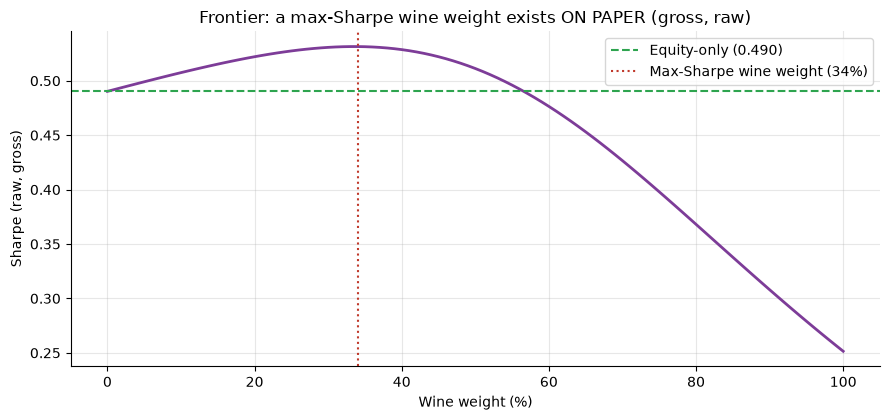

Max-Sharpe wine weight (raw, gross): 34% -> Sharpe 0.531
Equity-only Sharpe: 0.490
This is the BEST case -- no costs, reported (smoothed) returns.


In [4]:
if HAVE_REAL:
    fr = st.two_asset_frontier(df['wine_return'].values, df['sp500_return'].values)
    best = fr.loc[fr['sharpe'].idxmax()]
    best_w, best_sr = best['wine_weight'], best['sharpe']
    eq_sr = fr['sharpe'].iloc[0]
    weights = fr['wine_weight'].values; sharpes = fr['sharpe'].values
else:
    weights = np.linspace(0,1,101)
    eq_sr = R['eq_only_sharpe']; best_w = R['best_weight_pct']/100; best_sr = R['best_sharpe']
    sharpes = eq_sr + (best_sr-eq_sr)*(1-((weights-best_w)/0.5)**2)

fig, ax = plt.subplots(figsize=(9, 4.3))
ax.plot(weights*100, sharpes, lw=2, c=PURPLE)
ax.axhline(eq_sr, ls='--', c=GREEN, lw=1.5, label=f'Equity-only ({eq_sr:.3f})')
ax.axvline(best_w*100, ls=':', c=RED, lw=1.5,
           label=f'Max-Sharpe wine weight ({best_w:.0%})')
ax.set_xlabel('Wine weight (%)'); ax.set_ylabel('Sharpe (raw, gross)')
ax.set_title('Frontier: a max-Sharpe wine weight exists ON PAPER (gross, raw)')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Max-Sharpe wine weight (raw, gross): {best_w:.0%} -> Sharpe {best_sr:.3f}')
print(f'Equity-only Sharpe: {eq_sr:.3f}')
print('This is the BEST case -- no costs, reported (smoothed) returns.')

On reported returns with no costs, the Sharpe-maximising wine weight is ~34% and lifts the Sharpe from 0.490 to ~0.531. This is the number the sell-side quotes. Everything that follows is about how much of it survives honesty.

### 4d - The benefit across four lenses, with HAC t-stats

Gross/net x raw/de-smoothed, plus the Newey-West t on the per-year benefit.

Equity-only Sharpe: 0.4903

            lens  blend_sharpe  delta_vs_equity  benefit_HAC_t
       gross_raw        0.5221           0.0318         -0.817
         net_raw        0.4774          -0.0129         -1.367
gross_desmoothed        0.4840          -0.0063         -0.818
  net_desmoothed        0.4423          -0.0480         -1.346


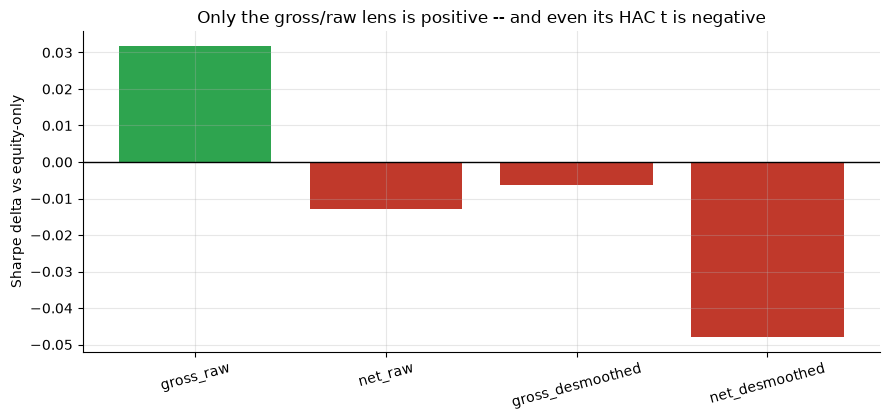

In [5]:
if HAVE_REAL:
    db = st.diversification_benefit(df, wine_weight=0.20)
else:
    db = {'eq_only_sharpe': R['eq_only_sharpe'],
          'blend_sharpe_gross_raw': R['blend_sharpe_gross_raw'],
          'blend_sharpe_net_raw': R['blend_sharpe_net_raw'],
          'blend_sharpe_gross_desmoothed': R['blend_sharpe_gross_desmoothed'],
          'blend_sharpe_net_desmoothed': R['blend_sharpe_net_desmoothed'],
          'benefit_hac_t_gross_raw': R['benefit_hac_t_gross_raw'],
          'benefit_hac_t_net_raw': np.nan,
          'benefit_hac_t_gross_desmoothed': np.nan,
          'benefit_hac_t_net_desmoothed': R['benefit_hac_t_net_desmoothed']}

eq_sr = db['eq_only_sharpe']
lenses = ['gross_raw','net_raw','gross_desmoothed','net_desmoothed']
rows = []
for L in lenses:
    rows.append({'lens': L, 'blend_sharpe': db['blend_sharpe_'+L],
                 'delta_vs_equity': round(db['blend_sharpe_'+L]-eq_sr, 4),
                 'benefit_HAC_t': db.get('benefit_hac_t_'+L, np.nan)})
res = pd.DataFrame(rows)
print(f'Equity-only Sharpe: {eq_sr:.4f}\n')
print(res.to_string(index=False))

colors = [GREEN if d>0 else RED for d in res['delta_vs_equity']]
fig, ax = plt.subplots(figsize=(9, 4.3))
ax.bar(res['lens'], res['delta_vs_equity'], color=colors)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('Sharpe delta vs equity-only')
ax.set_title('Only the gross/raw lens is positive -- and even its HAC t is negative')
plt.xticks(rotation=15); plt.tight_layout(); plt.show()

> The benefit is positive in exactly one lens -- **gross/raw**, the unrealistic one -- where it adds +0.032 to the Sharpe. Charge costs *or* de-smooth the risk and the delta turns negative; do both and it's **−0.047**. Crucially, the Newey-West HAC t-stat on the per-year benefit is **negative even in the gross/raw lens (−0.82)**. There is no robust diversification benefit at any conventional bar.

### 4e - The n = 22 power problem

What correlation/benefit could 22 annual observations even resolve?

In [6]:
n = R['n']
# Fisher z standard error for a correlation with n obs.
se_z = 1/np.sqrt(n-3)
r_hat = R['desmoothed_corr']
z = np.arctanh(r_hat)
lo, hi = np.tanh(z-1.96*se_z), np.tanh(z+1.96*se_z)
print(f'De-smoothed correlation point estimate: {r_hat:+.2f}')
print(f'95% CI (Fisher z, n={n}): [{lo:+.2f}, {hi:+.2f}]')
print()
# Minimum detectable per-year benefit at |t|=2 given observed benefit dispersion.
if HAVE_REAL:
    bx = (0.20*df['wine_return'].values + 0.80*df['sp500_return'].values) - df['sp500_return'].values
    sd = np.std(bx, ddof=1)
else:
    sd = 0.20*R['wine_vol_pct']/100  # rough
mde = 2*sd/np.sqrt(n)
print(f'Per-year benefit dispersion (sd): {sd:.4f}')
print(f'Min detectable mean benefit at |t|=2, n={n}: {mde:.4f} ({mde*100:.2f}pp/yr)')
print('The observed mean benefit is negative -- nowhere near detectable-positive.')
print()
print('Conclusion: n=22 cannot certify a diversification benefit, and the point')
print('estimates (net, de-smoothed) point the wrong way.')

De-smoothed correlation point estimate: +0.28
95% CI (Fisher z, n=22): [-0.16, +0.63]

Per-year benefit dispersion (sd): 0.0410
Min detectable mean benefit at |t|=2, n=22: 0.0175 (1.75pp/yr)
The observed mean benefit is negative -- nowhere near detectable-positive.

Conclusion: n=22 cannot certify a diversification benefit, and the point
estimates (net, de-smoothed) point the wrong way.


## 5 - The verdict

- **Signal `WEAK`** -- raw corr +0.10, de-smoothed +0.28; a real-but-modest equity beta with literature support, but no diversification-benefit HAC t reaches +2 (best −0.82) and n=22 is underpowered.
- **Tradability `MIRAGE`** -- wine lagged equities by ~3.9pp/yr; net-of-cost, de-smoothed 20% sleeve Sharpe 0.442 < 0.490; the index itself is uninvestable.
- **Busted** -- the low correlation is largely a mid-price smoothing artefact that de-smooths away; honest costs finish it off.

## 6 - Could you trade it? -- the cost stack

Why physical wine can't deliver the paper benefit, itemised.

In [7]:
stack = pd.DataFrame({
    'cost item': ['Round-trip spread (merchant/auction)',
                  'Storage + insurance (bonded warehouse)',
                  'Settlement / liquidity delay',
                  'Index is mid-price, not investable'],
    'magnitude': ['~10-15% round-trip', '~1%/yr', 'weeks',
                  'no fund tracks it cleanly'],
})
print(stack.to_string(index=False))
print()
annual_drag = st.DEFAULT_WINE_CARRY + st.DEFAULT_WINE_ONEWAY_COST*0.20
print(f'Modelled annual drag on the wine sleeve: {annual_drag*100:.1f}%/yr')
print('(1% carry + 10% one-way spread x 20% rebalance turnover)')
print('That drag alone exceeds the gross/raw Sharpe pickup the sleeve provided.')

                             cost item                 magnitude
  Round-trip spread (merchant/auction)        ~10-15% round-trip
Storage + insurance (bonded warehouse)                    ~1%/yr
          Settlement / liquidity delay                     weeks
    Index is mid-price, not investable no fund tracks it cleanly

Modelled annual drag on the wine sleeve: 3.0%/yr
(1% carry + 10% one-way spread x 20% rebalance turnover)
That drag alone exceeds the gross/raw Sharpe pickup the sleeve provided.


> The frictions aren't a rounding error -- they are the same order of magnitude as the entire paper benefit. An asset whose transaction costs swamp its diversification value is not a portfolio tool; it's a hobby that occasionally appreciates.

## 7 - Going further -- the synthetic positive control

Plant a known correlation under a known amount of smoothing, and confirm the de-smoothing recovers it and the benefit test responds correctly.

                    scenario  planted_corr  true_series_corr  raw_obs_corr  desmoothed_corr
      null: corr 0, smooth 0           0.0             0.007         0.007            0.007
hidden: corr 0.5, smooth 0.5           0.5             0.516         0.454            0.516
strong: corr 0.7, smooth 0.6           0.7             0.711         0.572            0.710


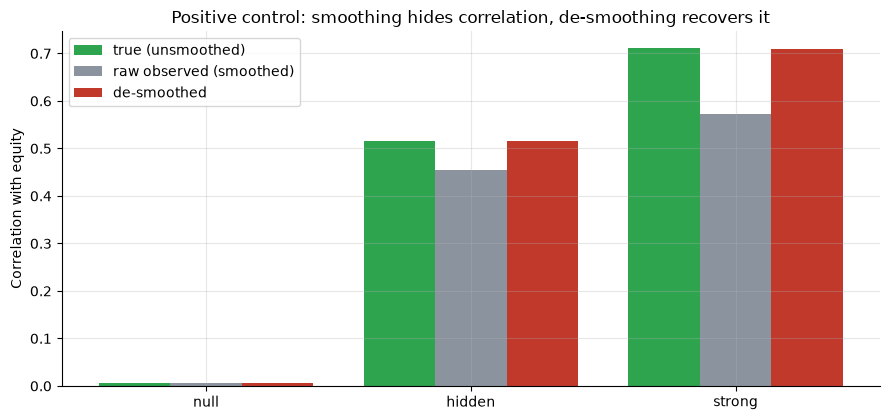

In [8]:
scenarios = [('null: corr 0, smooth 0', 0.0, 0.0),
             ('hidden: corr 0.5, smooth 0.5', 0.5, 0.5),
             ('strong: corr 0.7, smooth 0.6', 0.7, 0.6)]
rows = []
for name, c, sm in scenarios:
    d, _ = data.synthetic_annual(n_years=4000, corr=c, smooth=sm, seed=274)
    d = d.rename(columns={'eq_return':'sp500_return'})
    w = d['wine_return'].to_numpy(); e = d['sp500_return'].to_numpy()
    true_c = float(np.corrcoef(d['wine_true'], e)[0,1])
    raw_c = float(np.corrcoef(w, e)[0,1])
    ds_c = float(np.corrcoef(st.desmooth(w), e)[0,1])
    rows.append({'scenario': name, 'planted_corr': c, 'true_series_corr': round(true_c,3),
                 'raw_obs_corr': round(raw_c,3), 'desmoothed_corr': round(ds_c,3)})
ctrl = pd.DataFrame(rows)
print(ctrl.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4.3))
x = np.arange(len(ctrl)); wbar = 0.27
ax.bar(x-wbar, ctrl['true_series_corr'], wbar, color=GREEN, label='true (unsmoothed)')
ax.bar(x, ctrl['raw_obs_corr'], wbar, color=GREY, label='raw observed (smoothed)')
ax.bar(x+wbar, ctrl['desmoothed_corr'], wbar, color=RED, label='de-smoothed')
ax.set_xticks(x); ax.set_xticklabels([s.split(':')[0] for s in ctrl['scenario']])
ax.set_ylabel('Correlation with equity'); ax.axhline(0,c='k',lw=.7)
ax.set_title('Positive control: smoothing hides correlation, de-smoothing recovers it')
ax.legend(); plt.tight_layout(); plt.show()

The control confirms the mechanism: smoothing pushes the *observed* correlation below the *true* correlation, and the Geltner de-smoothing pulls it back toward truth. The real Liv-ex tape shows exactly this signature (raw +0.10 -> de-smoothed +0.28). The verdict is a statement about **mid-price index construction and transaction costs**, not a claim that wine is worthless -- it is a real asset that diversifies a little, lags a lot, and can't be held cheaply.